In [1]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import IPython.display as ipd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Configuration
DATASET_PATH = "dataset"
COMMANDS = ["baca", "berhenti", "foto", "halo", "info", "kembali", "ulang"]
SAMPLE_RATE = 16000
N_MFCC = 13
N_MELS = 22
WINDOW = int(SAMPLE_RATE * 0.01)  # 10ms window
HOP = 256  # Hop length for MFCC

# Load one audio file per label
def load_audio_files():
    audio_data = {}
    for label in COMMANDS:
        label_path = os.path.join(DATASET_PATH, label)
        if not os.path.exists(label_path):
            print(f"Directory {label_path} does not exist.")
            continue
        wav_files = glob.glob(os.path.join(label_path, "*.wav"))
        if wav_files:
            try:
                signal, sr = librosa.load(wav_files[0], sr=SAMPLE_RATE)
                audio_data[label] = (signal, sr)
            except Exception as e:
                print(f"Error loading {wav_files[0]}: {e}")
        else:
            print(f"No .wav files found in {label_path}")
    return audio_data

# Augmentation functions
def speedNpitch(data):  # Augmentation 1
    length_change = np.random.uniform(low=0.8, high=1)
    speed_fac = 1.2 / length_change
    tmp = np.interp(np.arange(0, len(data), speed_fac), np.arange(0, len(data)), data)
    minlen = min(len(data), len(tmp))
    data_aug = np.zeros_like(data)
    data_aug[0:minlen] = tmp[0:minlen]
    return data_aug

def add_noise(data):  # Augmentation 2
    noise = np.random.normal(0, 0.005, len(data))
    return data + noise

def time_shift(data):  # Augmentation 3
    shift = int(len(data) * 0.1)
    if np.random.rand() > 0.5:
        return np.roll(data, shift)
    else:
        return np.roll(data, -shift)

def pitch_shift(data, sr=SAMPLE_RATE):  # Augmentation 4
    n_steps = np.random.randint(-2, 3)
    return librosa.effects.pitch_shift(data, sr=sr, n_steps=n_steps)

def time_stretch(data):  # Augmentation 5
    rate = np.random.uniform(0.8, 1.2)
    return librosa.effects.time_stretch(data, rate=rate)

def volume_adjust(data):  # Augmentation 6
    gain = np.random.uniform(0.5, 1.5)
    return data * gain

# MFCC extraction function
def extract_mfcc(signal):
    return librosa.feature.mfcc(
        y=signal,
        sr=SAMPLE_RATE,
        n_mfcc=N_MFCC,
        n_mels=N_MELS,
        n_fft=WINDOW,
        hop_length=HOP
    ).T

# Encoding and padding function
def encode_and_pad(df_train, df_valid):
    le = LabelEncoder()
    df_train['label_encoded'] = le.fit_transform(df_train['label'])
    df_valid['label_encoded'] = le.transform(df_valid['label'])
    all_mfcc = df_train['mfcc'].tolist() + df_valid['mfcc'].tolist()
    max_len = max(len(x) for x in all_mfcc)
    X_train = pad_sequences(df_train['mfcc'], maxlen=max_len, padding='post', dtype='float32')
    X_valid = pad_sequences(df_valid['mfcc'], maxlen=max_len, padding='post', dtype='float32')
    y_train = to_categorical(df_train['label_encoded'])
    y_valid = to_categorical(df_valid['label_encoded'])
    return X_train, y_train, X_valid, y_valid, le

# Create dataframe with MFCCs
def create_mfcc_dataframe(audio_data):
    data = []
    for label, (signal, sr) in audio_data.items():
        try:
            mfcc = extract_mfcc(signal)
            data.append({'label': label, 'mfcc': mfcc})
        except Exception as e:
            print(f"Error extracting MFCC for {label}: {e}")
    return pd.DataFrame(data)

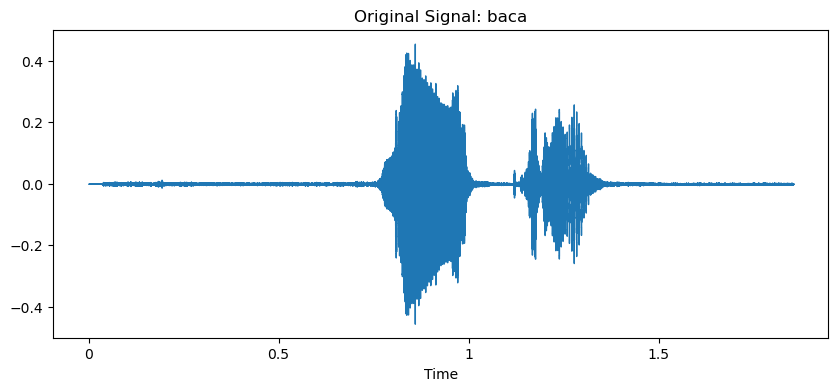

Playing original audio for baca


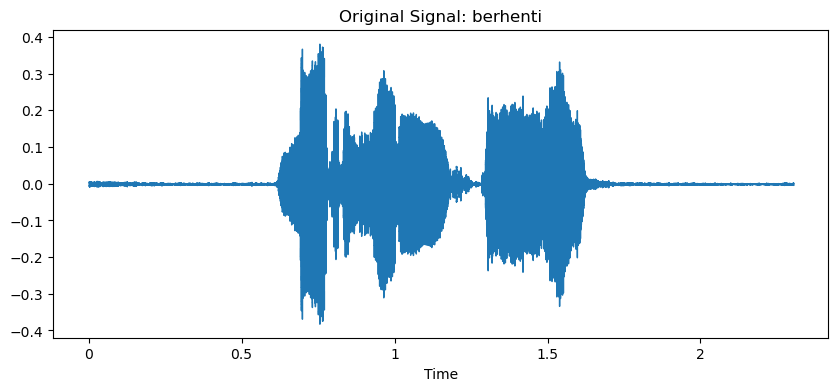

Playing original audio for berhenti


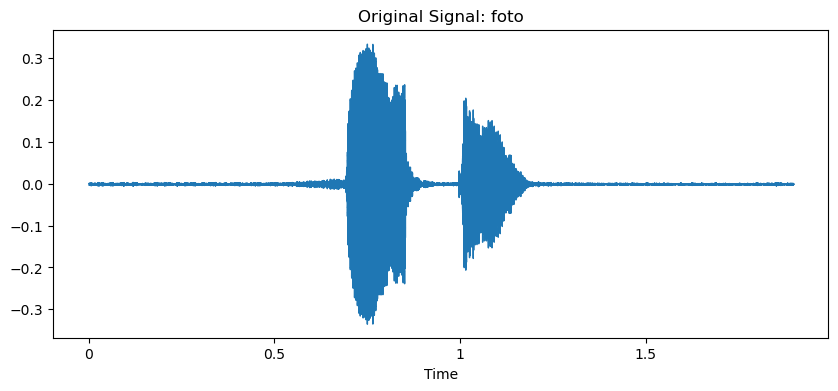

Playing original audio for foto


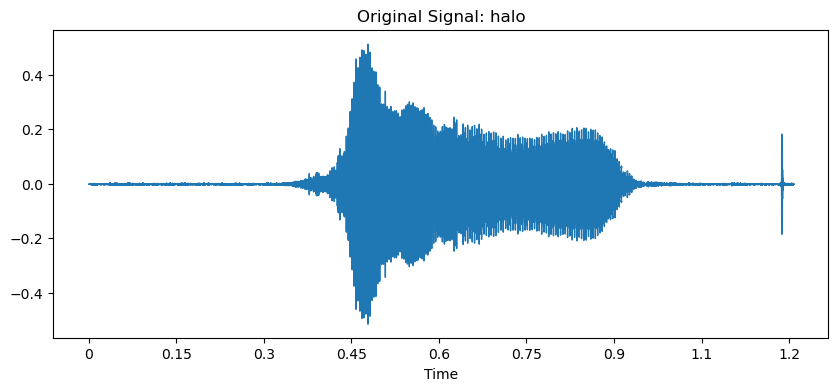

Playing original audio for halo


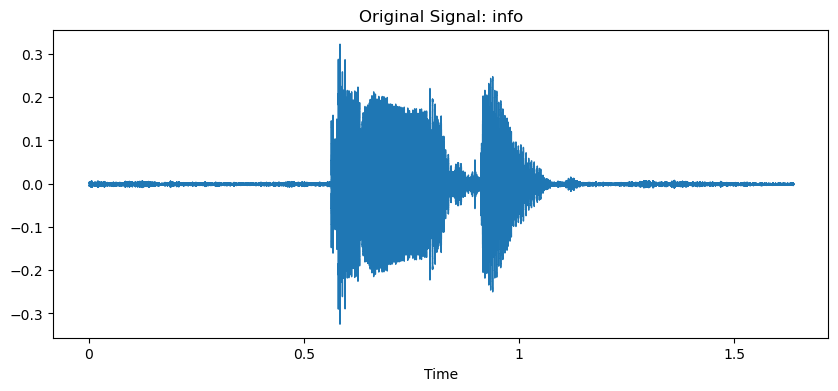

Playing original audio for info


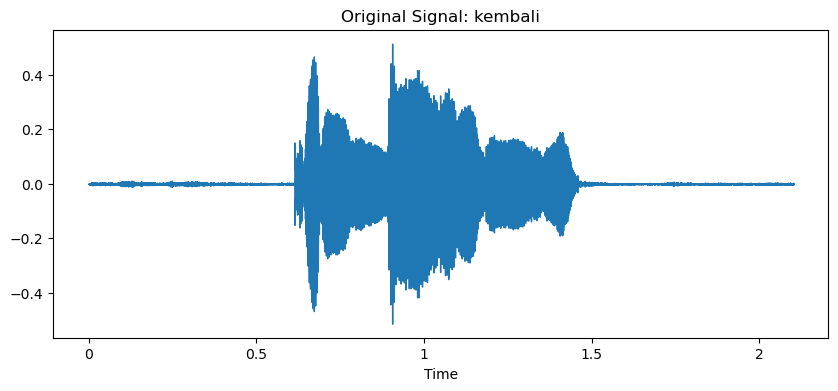

Playing original audio for kembali


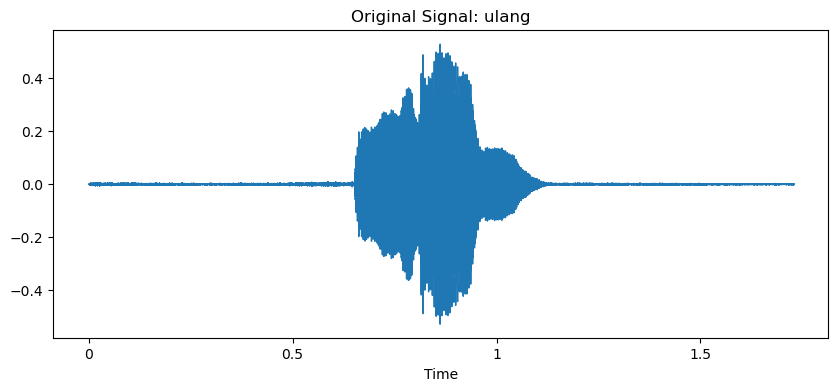

Playing original audio for ulang


In [2]:
# Display original signal for each label
audio_data = load_audio_files()
for label, (signal, sr) in audio_data.items():
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Original Signal: {label}")
    plt.show()
    print(f"Playing original audio for {label}")
    display(ipd.Audio(signal, rate=sr))

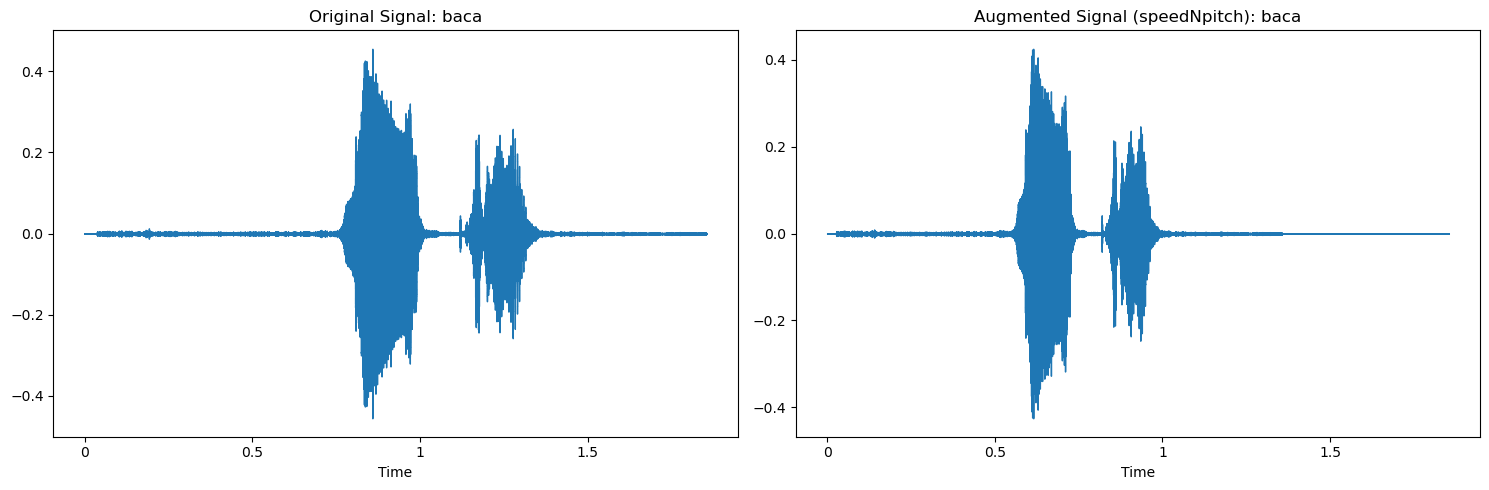

In [3]:
# Augmentation 1: speedNpitch (for label 'baca')
label = 'baca'
if label in audio_data:
    signal, sr = audio_data[label]
    augmented_signal = speedNpitch(signal)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Original Signal: {label}")
    plt.subplot(1, 2, 2)
    librosa.display.waveshow(augmented_signal, sr=sr)
    plt.title(f"Augmented Signal (speedNpitch): {label}")
    plt.tight_layout()
    plt.show()

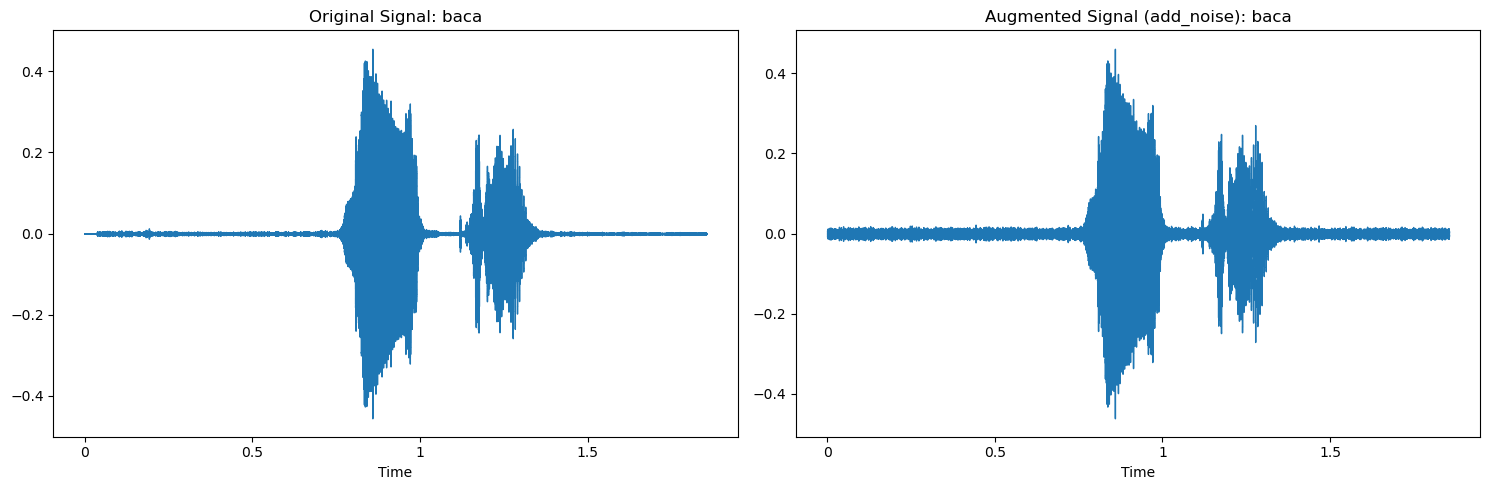

In [4]:
# Augmentation 2: add_noise (for label 'baca')
label = 'baca'
if label in audio_data:
    signal, sr = audio_data[label]
    augmented_signal = add_noise(signal)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Original Signal: {label}")
    plt.subplot(1, 2, 2)
    librosa.display.waveshow(augmented_signal, sr=sr)
    plt.title(f"Augmented Signal (add_noise): {label}")
    plt.tight_layout()
    plt.show()

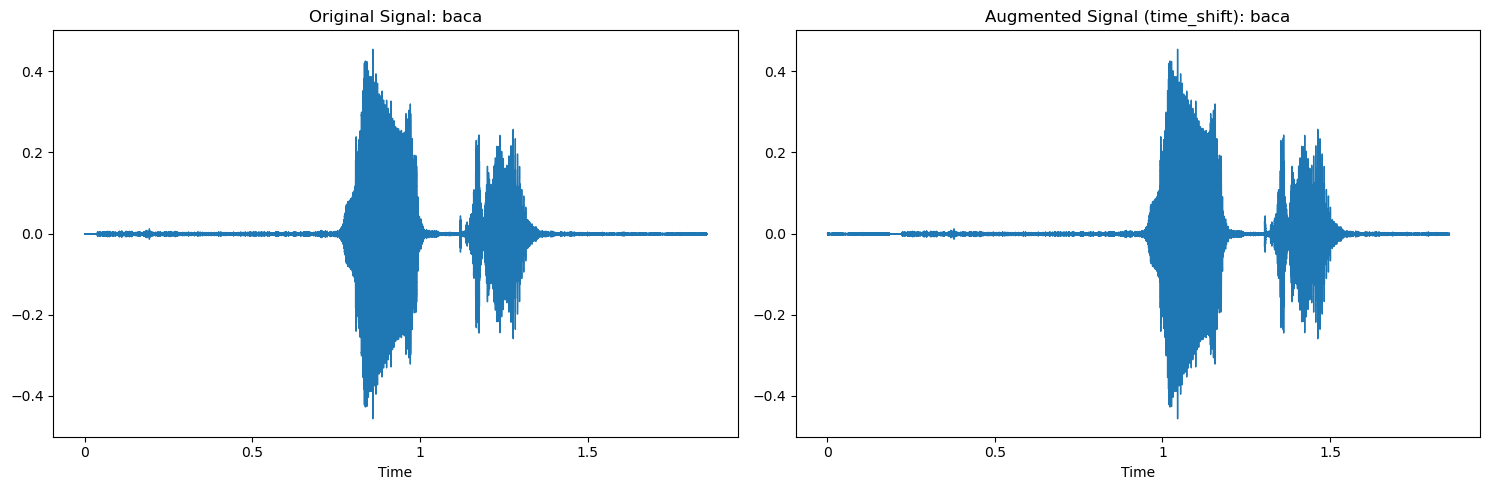

In [5]:
# Augmentation 3: time_shift (for label 'baca')
label = 'baca'
if label in audio_data:
    signal, sr = audio_data[label]
    augmented_signal = time_shift(signal)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Original Signal: {label}")
    plt.subplot(1, 2, 2)
    librosa.display.waveshow(augmented_signal, sr=sr)
    plt.title(f"Augmented Signal (time_shift): {label}")
    plt.tight_layout()
    plt.show()

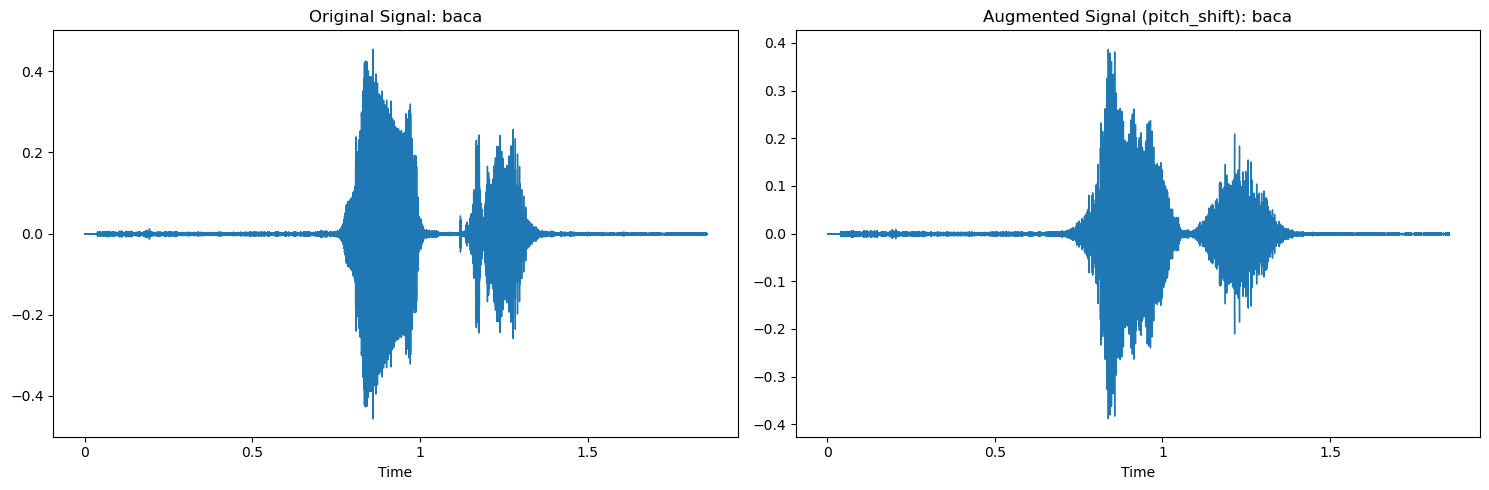

In [6]:
# Augmentation 4: pitch_shift (for label 'baca')
label = 'baca'
if label in audio_data:
    signal, sr = audio_data[label]
    augmented_signal = pitch_shift(signal, sr)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Original Signal: {label}")
    plt.subplot(1, 2, 2)
    librosa.display.waveshow(augmented_signal, sr=sr)
    plt.title(f"Augmented Signal (pitch_shift): {label}")
    plt.tight_layout()
    plt.show()

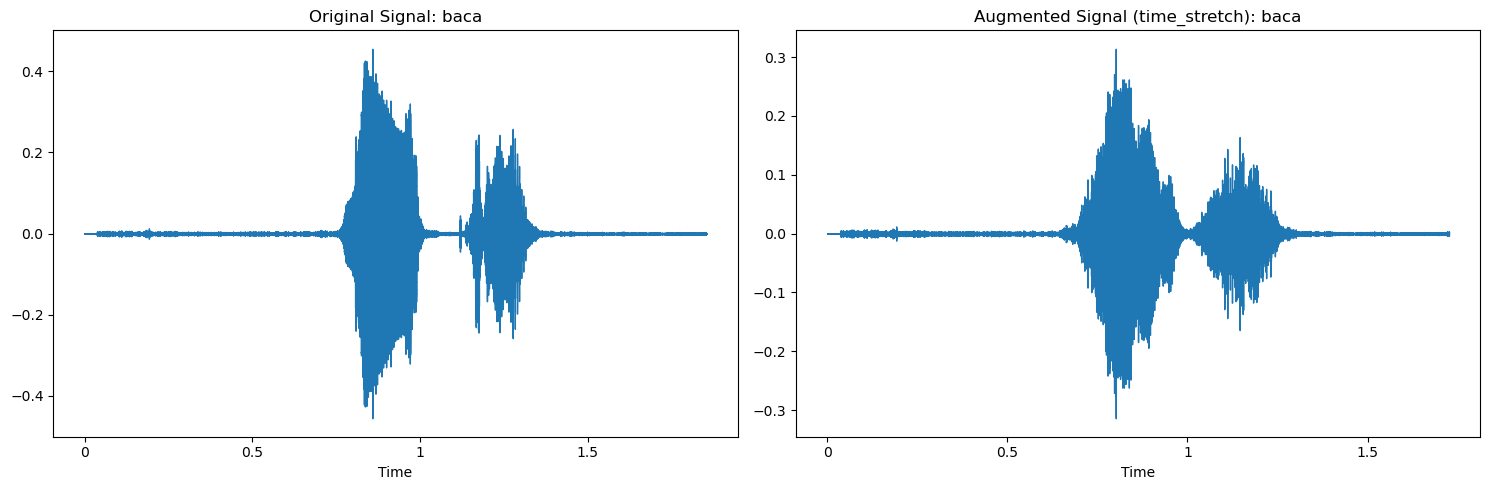

In [7]:
# Augmentation 5: time_stretch (for label 'baca')
label = 'baca'
if label in audio_data:
    signal, sr = audio_data[label]
    augmented_signal = time_stretch(signal)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Original Signal: {label}")
    plt.subplot(1, 2, 2)
    librosa.display.waveshow(augmented_signal, sr=sr)
    plt.title(f"Augmented Signal (time_stretch): {label}")
    plt.tight_layout()
    plt.show()

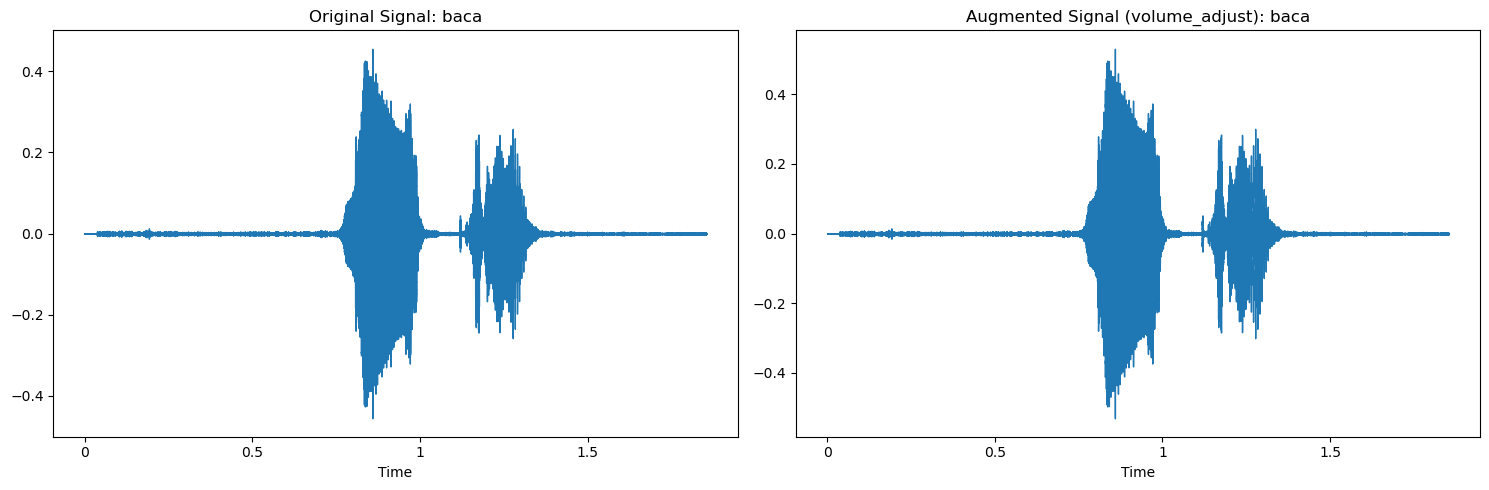

In [8]:
# Augmentation 6: volume_adjust (for label 'baca')
label = 'baca'
if label in audio_data:
    signal, sr = audio_data[label]
    augmented_signal = volume_adjust(signal)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Original Signal: {label}")
    plt.subplot(1, 2, 2)
    librosa.display.waveshow(augmented_signal, sr=sr)
    plt.title(f"Augmented Signal (volume_adjust): {label}")
    plt.tight_layout()
    plt.show()

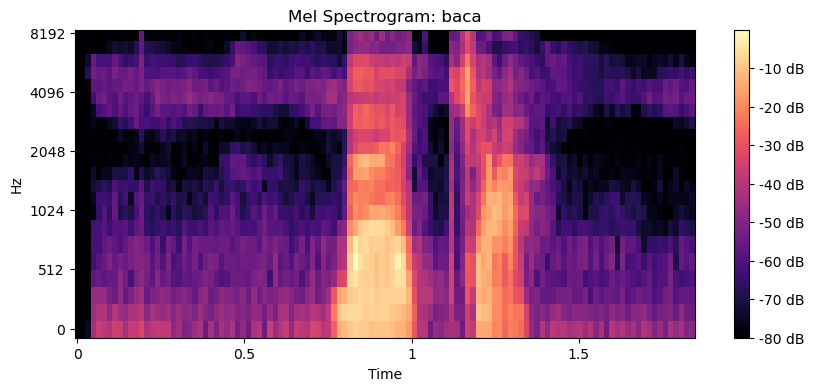

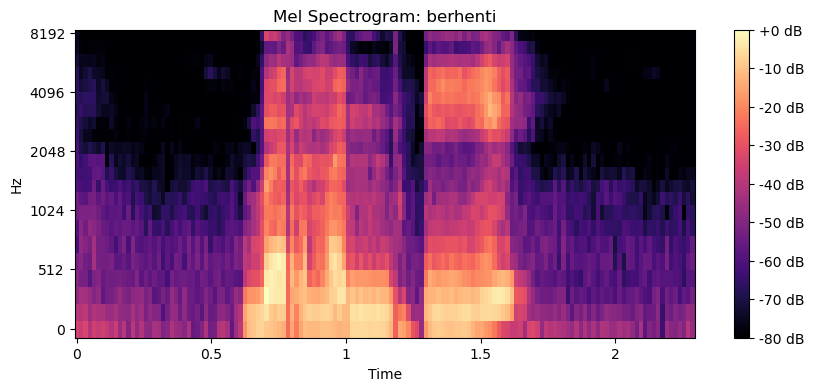

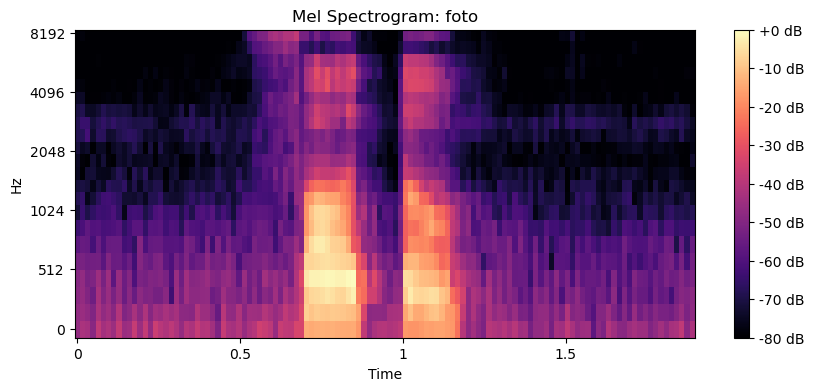

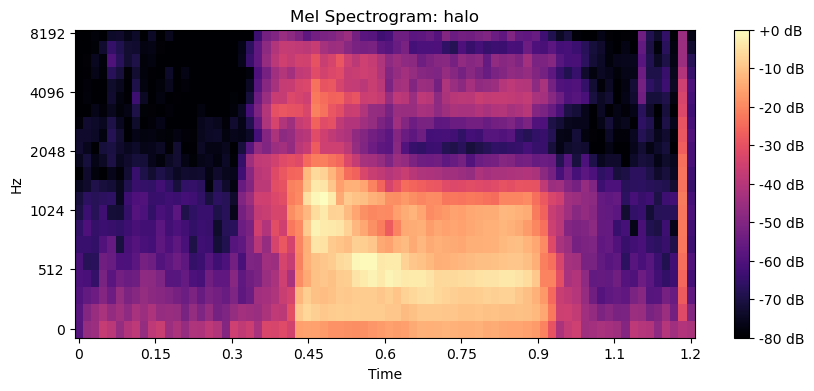

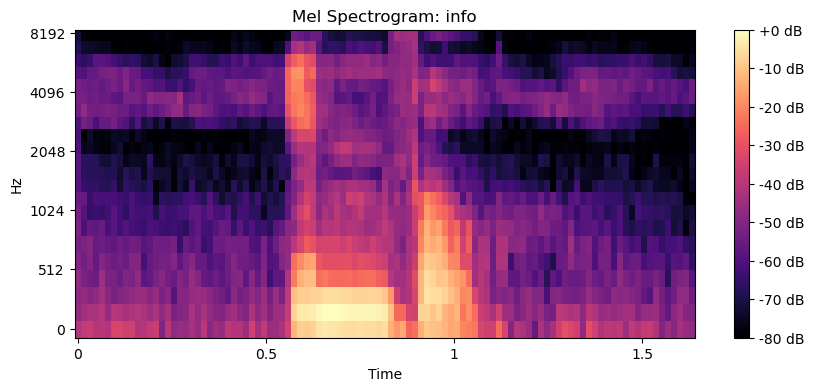

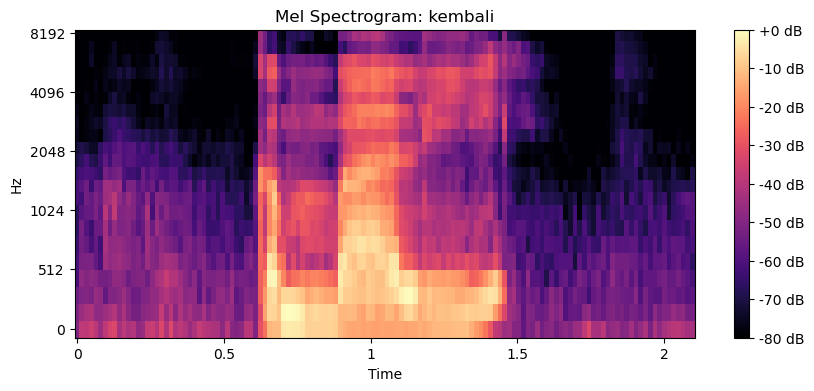

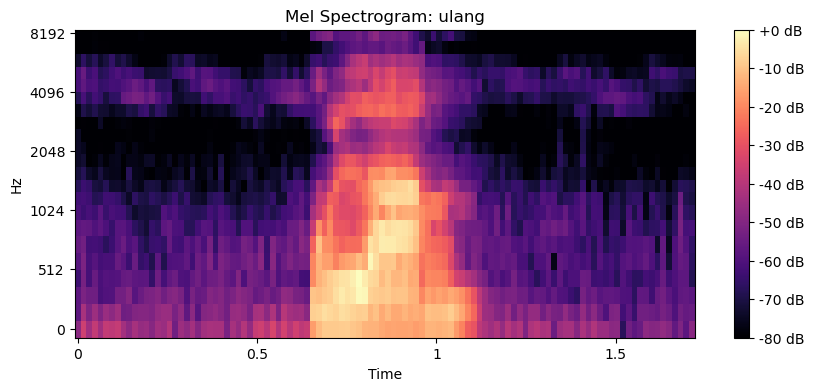

In [9]:
# Display mel spectrogram for each label
for label, (signal, sr) in audio_data.items():
    plt.figure(figsize=(10, 4))
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=N_MELS, n_fft=WINDOW, hop_length=HOP)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(mel_spec_db, sr=sr, hop_length=HOP, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Mel Spectrogram: {label}")
    plt.show()

In [10]:
# Create and display MFCC dataframe
df_mfcc = create_mfcc_dataframe(audio_data)
print("MFCC DataFrame:")
display(df_mfcc)

MFCC DataFrame:


,label,mfcc
0,baca,"[[-385.64957, 0.0, -9.107739e-06, 0.0, 0.0, 0...."
1,berhenti,"[[-290.6537, 43.3011, 6.1797523, 13.070197, 6...."
2,foto,"[[-336.7292, 46.622414, 14.83947, 15.672823, -..."
3,halo,"[[-359.14804, 35.221832, 10.320348, 3.0360827,..."
4,info,"[[-280.09152, 26.1128, 4.060148, 11.953274, -1..."
5,kembali,"[[-330.4393, 42.331512, 2.659122, 3.4952478, 1..."
6,ulang,"[[-322.49048, 31.25511, 11.654533, -1.3667905,..."


In [11]:
# Encode, pad, and create final dataframe
df_train = df_mfcc.sample(frac=0.8, random_state=42)
df_valid = df_mfcc.drop(df_train.index)
X_train, y_train, X_valid, y_valid, le = encode_and_pad(df_train, df_valid)
final_data = []
for i, label in enumerate(df_train['label']):
    final_data.append({
        'label': label,
        'label_encoded': le.transform([label])[0],
        'mfcc_shape': X_train[i].shape,
        'y_shape': y_train[i].shape
    })
for i, label in enumerate(df_valid['label']):
    final_data.append({
        'label': label,
        'label_encoded': le.transform([label])[0],
        'mfcc_shape': X_valid[i].shape,
        'y_shape': y_valid[i].shape
    })
final_df = pd.DataFrame(final_data)
print("Final Encoded and Padded DataFrame:")
display(final_df)

ValueError: y contains previously unseen labels: 'ulang'